In [19]:
# add evaluate to path
import sys
sys.path.append('/home/mehmet/codebase/dna2vec/evaluate')
from transformers import AutoModel, AutoTokenizer
import torch.nn as nn
import yaml
from pathlib import Path
from inference_models import HFModel
import torch
import os
from tqdm import tqdm
import numpy as np
import re
from collections import defaultdict
from dataclasses import dataclass
from typing import Tuple, Union, Optional, Literal, List
from pysam import AlignedSegment
from dna2vec.simulate import load_human_reference_genome
from dna2vec.simulate import load_real_reads_from_disk



In [20]:
@dataclass
class ReadAndReference:
    """
    Class for storing a read and its reference.

    Attributes:
        read: The read.
        reference: The reference sequence as a string.
    """

    read: AlignedSegment
    reference: Union[str, None] = None
    id: Union[str, None] = None

    def is_mapped(self) -> bool:
        return self.reference is not None

    def get_pair_as_string(self) -> Tuple[str, Union[str, None]]:
        """
        Get the pair as a tuple of strings.
        """
        return (self.read.query_sequence, self.reference)

In [39]:
def real_mapped_reads_sv(
    bam_file: Union[Path, None] = None,
    evidence_bam_file: Union[Path, None] = None,
    reference_genome: Union[Path, None] = None,
    chr_number: int = 2,
    type_of_sv: Literal["deletion", "insertion", "skipped_region", "soft_clip", "all"] = "insertion",
    size_of_sv: int = 20,
    max_reads: int = 500,
    vcf_path: Optional[Path] = None,
    bed_path: Optional[Path] = None,
):

    mapped_reads, reference_sv_pos_reads, read_ref_dict_loc, read_ref_dict_loc_sv_pos, read_labels = map_real_reads_to_reference_sv( #TODO: Remove this
            reads=load_real_reads_from_disk(bam_file),
            evidence_reads=load_real_reads_from_disk(evidence_bam_file),
            vcf_path=vcf_path,
            reference=reference_genome,
            chr_number=chr_number,
            type_of_sv=type_of_sv,
            size_of_sv=size_of_sv,
            max_reads=max_reads,
            bed_path=bed_path,
        )
    
    return mapped_reads, reference_sv_pos_reads, read_ref_dict_loc, read_ref_dict_loc_sv_pos, read_labels

def map_real_reads_to_reference_sv(
    reads: List[AlignedSegment],
    evidence_reads: List[AlignedSegment],
    reference: Optional[Path] = None,
    vcf_path: Optional[Path] = None,
    bed_path: Optional[Path] = None,
    chr_number: int = 2,
    type_of_sv: Literal["deletion", "insertion", "skipped_region", "soft_clip", "all"] = "insertion",
    size_of_sv: int = 20,
    max_reads: int = 500,
    sv_type_str: str = "INS",
) -> List[ReadAndReference]:
    """
    Map a read to a reference genome.
    """
    reference = load_human_reference_genome(reference)
    
    evidence_reads_temp = [read for read in evidence_reads]
    evidence_reads = evidence_reads_temp

    evidence_read_tags = {read.qname:read.tags for read in evidence_reads}
    # for every read, get the tuple which start with "ZM" and get the identifier 
    evidence_read_evidence_tags = {k:v[-1][-1].split("|")[0] for k,v in evidence_read_tags.items() if sv_type_str in v[-1][-1]}
    # create a dictionary where we groupby keys using unique values
    evidence_read_tags_sv_to_id = {}
    for unique_tag in set(evidence_read_evidence_tags.values()):
        evidence_read_tags_sv_to_id[unique_tag] = [
            read_id for read_id, tag in evidence_read_evidence_tags.items() 
            if tag == unique_tag
        ]
    # drop keys with DEL and TANDEM
    
    evidence_read_tags_sv_to_id = {k:v for k,v in evidence_read_tags_sv_to_id.items() if "DEL" not in k and "TANDEM" not in k}
    
    # make a id set using all the values
    evidence_read_tags_sv_to_id_list = []
    for value in evidence_read_tags_sv_to_id.values():
        evidence_read_tags_sv_to_id_list.extend(value)
    evidence_read_tags_sv_to_id_set = set(evidence_read_tags_sv_to_id_list)

    id2read = defaultdict(list)
    unmapped_reads = []

    # === Step 1: First load high-confidence regions from BED file ===
    high_conf_regions = defaultdict(list)
    if bed_path:
        with open(bed_path, "r") as f:
            for line in f:
                parts = line.strip().split("\t")
                chrom = parts[0]
                high_conf_reg_start = int(parts[1])
                high_conf_reg_end = int(parts[2])
                high_conf_regions[chrom].append((high_conf_reg_start, high_conf_reg_end))
    
    # === Step 2: Load SVs from VCF that fall within high-confidence regions ===
    svs = []
    with open(vcf_path, "r") as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            chrom = parts[0]
            if chrom != str(chr_number) and chrom != "chr" + str(chr_number):  # Accept both notations
                continue
            
            start = int(parts[1])
            info = dict(x.split("=") for x in parts[7].split(";") if "=" in x)
            end = int(info["END"])
            svlen = int(info["SVLEN"])
            sv_type = info["SVTYPE"]
            
            if abs(svlen) > 50 and sv_type == sv_type_str:
                # Check if this SV falls within any high-confidence region
                for chrom_key in [str(chr_number), f"chr{chr_number}"]:
                    for high_conf_reg_start, high_conf_reg_end in high_conf_regions.get(chrom_key, []):
                        if high_conf_reg_start <= start <= high_conf_reg_end:
                            svs.append((chrom, start, end))
                            break
    
    print(f"Loaded {len(svs)} {type_of_sv}s on chr{chr_number}.")
    
    # === Step 3: Extract reads with deletions, soft clips, or skipped regions ===
    read_ref_dict_loc = defaultdict(lambda: ([], []))
    read_ref_dict_loc_sv_pos = defaultdict(lambda: ([], []))
    read_labels = []
    
    for chrom, start, end in tqdm(svs, desc=f"Processing {type_of_sv}s on chr{chr_number}"):
        try:
            for read in tqdm(reads.fetch(chrom, start-500, end+500), desc="Processing reads"):
                if True: #has_structural_variant and read.cigarstring and read.is_mapped and read.mapq >= 70:
                    _id = chrom
                    unmapped_read = ReadAndReference(read=read)
                    id2read[_id].append(unmapped_read)
                    unmapped_reads.append(unmapped_read)
                    read_ref_dict_loc[f"{chrom}:{start}-{end}"][0].append(read.query_sequence)
                    read_ref_dict_loc_sv_pos[f"{chrom}:{start}-{end}"][0].append([read.reference_start, read.reference_end])
                    # check if we have a match at the start of the read from cigarstring
                    try:
                        if read.cigartuples[0][0] == 0:
                            read_range = range(read.reference_start, read.reference_start + read.query_length)
                        else:
                            read_range = range(read.reference_end - read.query_length, read.reference_end)
                        
                    except:
                        read_range = range(read.reference_start, read.reference_start + read.query_length)
                    
                    if start != end:    
                        sv_range = range(start, end)
                    else:
                        sv_range = range(start, end+1) # ensure that it has at least one element
                        
                        # if any element of read_range is in sv_range and not full match by cigarstring, then it is class SV otherwise Normal
                    try:
                        cigar_string_tuples = re.findall(r'(\d+)([MIDNSHP=X])', read.cigarstring)
                        cigar_string_letters = [x[1] for x in cigar_string_tuples]
                        is_full_match = True if "M" in cigar_string_letters and len(cigar_string_letters) == 1 else False
                    except:
                        is_full_match = False
                        cigar_string_tuples = None
                        
                    if any(x in sv_range for x in read_range) and not is_full_match:
                        if cigar_string_tuples:
                            ops_len = 0
                            for ops in cigar_string_tuples:
                                if ops[1] != "M":
                                    ops_len += int(ops[0])
                            
                            if ops_len > 10:
                                read_labels.append("SV")
                            else:
                                read_labels.append("Normal")
                                
                        else:
                            read_labels.append("SV")
                    else:
                        read_labels.append("Normal")
                        
                    if len(unmapped_reads) >= max_reads:
                        break
                    
            if len(unmapped_reads) >= max_reads:
                break
        except ValueError:
            print(f"Region doesn't exist in BAM: {chrom}:{start}-{end}")
            continue
        
    # check any of the evidence_read_tags_sv_to_id_set is in mapped_reads
    mapped_reads_id_set = set([read.read.qname for read in unmapped_reads])
    # check if any of the evidence_read_tags_sv_to_id_set is in mapped_reads_id_set
    to_be_added_evidence_read_tags_sv_to_id_set = evidence_read_tags_sv_to_id_set - mapped_reads_id_set
    print("TO BE ADDED EVIDENCE READ TAGS SV TO ID SET LEN:",len(to_be_added_evidence_read_tags_sv_to_id_set))
    # get these reads from evidence_reads
    to_be_added_evidence_reads = [read for read in evidence_reads if read.qname in to_be_added_evidence_read_tags_sv_to_id_set]
    count = 0
    for chrom, start, end in svs:
        for read in to_be_added_evidence_reads:
            if read.reference_start >= start-1000 and read.reference_start <= end+1000:
                _id = chrom
                unmapped_read = ReadAndReference(read=read)
                id2read[_id].append(unmapped_read)
                unmapped_reads.append(unmapped_read)
                read_ref_dict_loc[f"{chrom}:{start}-{end}"][0].append(read.query_sequence)
                read_ref_dict_loc_sv_pos[f"{chrom}:{start}-{end}"][0].append([read.reference_start, read.reference_end])
                # check if we have a match at the start of the read from cigarstring
                read_labels.append("SV")
                count += 1
                
    print(f"Added {count} reads to the dataset")
    print(f"Total reads in the evidence dataset: {len(to_be_added_evidence_reads)}")

    reference_sv_pos_reads = []
    for seq in reference:
        for chrom, start, end in tqdm(svs, desc=f"Processing {type_of_sv}s on chr{chr_number}"):
            if seq.id == chrom:
                try:
                    for i in range(start - 500, end + 500, 50):
                        seq_read = seq.seq[i:i+250]
                        reference_sv_pos_reads.append(seq_read)
                        read_ref_dict_loc[f"{chrom}:{start}-{end}"][1].append(seq_read)
                        read_ref_dict_loc_sv_pos[f"{chrom}:{start}-{end}"][1].append([i, i+250])
                        
                    for read in tqdm(reads.fetch(chrom, start-500, end+500), desc="Processing reads"):
                        try:
                            # if cigarstring starts with soft clip go from end to start
                            if read.cigartuples[0][0] == 4:
                                seq_read = seq.seq[read.reference_end - read.query_length:read.reference_end]
                            else:
                                seq_read = seq.seq[read.reference_start:read.reference_start+read.query_length]
                        except:
                            seq_read = seq.seq[read.reference_start:read.reference_start+read.query_length]
                        reference_sv_pos_reads.append(seq_read)
                        read_ref_dict_loc[f"{chrom}:{start}-{end}"][1].append(seq_read)
                        read_ref_dict_loc_sv_pos[f"{chrom}:{start}-{end}"][1].append([read.reference_start, read.reference_end])
                except ValueError:
                    print(f"Region doesn't exist in BAM: {chrom}:{start}-{end}")
                    continue
    
    seq_offset = 0
    for seq in reference:
        matches = id2read[seq.id]
        for match in matches:
            read = match.read
            start = read.reference_start
            length = read.query_length
            original_sequence = seq.seq[start : start + length]
            match.reference = str(original_sequence)
            match.id = seq.id
            match.seq_offset = seq_offset
            assert read.query_sequence == read.seq
        seq_offset += len(seq.seq)
    return unmapped_reads, reference_sv_pos_reads, read_ref_dict_loc, read_ref_dict_loc_sv_pos, read_labels

In [40]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# %env CUDA_LAUNCH_BLOCKING=1

In [41]:
# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
with open('/home/mehmet/codebase/dna2vec/evaluate/configs/refined_evaluate.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

In [43]:
def load_hf_model():
    hf_model = AutoModel.from_pretrained("roychowdhuryresearch/dna2vec", trust_remote_code=True)
    hf_tokenizer = AutoTokenizer.from_pretrained("roychowdhuryresearch/dna2vec", trust_remote_code=True)

    class AveragePooler(nn.Module):
        """
        Parameter-free poolers to get the sentence embedding
        # derived from https://github.com/princeton-nlp/SimCSE/blob/13361d0e29da1691e313a94f003e2ed1cfa97fef/simcse/models.py#LL49C1-L84C1
        """

        def __init__(self):
            super().__init__()

        def forward(self, last_hidden, attention_mask):
            # Old previous implementation
            return (last_hidden * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(
                -1
            ).unsqueeze(-1)

    hf_model.pooler = AveragePooler()
    return hf_model, hf_tokenizer, hf_model.pooler

In [44]:
model, tokenizer, pooling = load_hf_model()
model = HFModel(tokenizer, model, pooling, "cuda")

/home/mehmet/miniconda3/envs/dna2vec/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True



In [45]:
bam_file = Path("/mnt/SSD7/yigit/dnarde/rde2/HG002.hs37d5.2x250.bam")
evidence_bam_file = Path("/home/mehmet/codebase/dna2vec/evaluate/playground/manta/data/evidence_0.HG002.hs37d5.2x250_chr19_withRG_sorted_dupMark.bam")
fasta_file_path = Path("/mnt/SSD7/yigit/dnarde/ch19/hs37d5.fasta")   
mapped_reads, reference_sv_pos_reads, read_ref_dict_loc, read_ref_dict_loc_sv_pos, read_labels = real_mapped_reads_sv(
    bam_file=bam_file,
    evidence_bam_file=evidence_bam_file,
    reference_genome=fasta_file_path,
    chr_number=cfg["experiment_settings"]["chr_number"],
    type_of_sv="all",
    size_of_sv=cfg["experiment_settings"]["size_of_sv"],
    max_reads=cfg["experiment_settings"]["max_reads"],
    vcf_path="/home/mehmet/codebase/dna2vec/HG002_SVs_Tier1_v0.6_cleaned.vcf", 
    # vcf_path="/home/mehmet/codebase/dna2vec/human_deletions_GS_correct.vcf",
    bed_path="/home/mehmet/codebase/dna2vec/HG002_SVs_Tier1_v0.6.bed",
)

/mnt/SSD7/yigit/dnarde/rde2/HG002.hs37d5.2x250.bam
/home/mehmet/codebase/dna2vec/evaluate/playground/manta/data/evidence_0.HG002.hs37d5.2x250_chr19_withRG_sorted_dupMark.bam
Reference genome path: /mnt/SSD7/yigit/dnarde/ch19/hs37d5.fasta
Loaded 227 alls on chr19.


Processing reads: 272it [00:00, 16691.55it/s]227 [00:00<?, ?it/s]
Processing reads: 375it [00:00, 19861.15it/s]
Processing reads: 3158it [00:00, 70555.21it/s]
Processing reads: 358it [00:00, 19959.34it/s]
Processing reads: 267it [00:00, 16045.03it/s]227 [00:00<00:06, 35.86it/s]
Processing reads: 377it [00:00, 27060.03it/s]
Processing reads: 283it [00:00, 24733.04it/s]
Processing reads: 350it [00:00, 13578.07it/s]
Processing reads: 296it [00:00, 26104.16it/s]
Processing reads: 383it [00:00, 19036.10it/s]
Processing reads: 283it [00:00, 20147.13it/s]/227 [00:00<00:04, 44.51it/s]
Processing reads: 340it [00:00, 17331.83it/s]
Processing reads: 343it [00:00, 19947.68it/s]
Processing reads: 288it [00:00, 16163.89it/s]
Processing reads: 369it [00:00, 17514.83it/s]
Processing reads: 196it [00:00, 23661.17it/s]/227 [00:00<00:04, 45.57it/s]
Processing reads: 392it [00:00, 33619.61it/s]
Processing reads: 389it [00:00, 27527.53it/s]
Processing reads: 343it [00:00, 22645.86it/s]
Processing reads: 2

TO BE ADDED EVIDENCE READ TAGS SV TO ID SET LEN: 932
Added 0 reads to the dataset
Total reads in the evidence dataset: 2397


Processing reads: 272it [00:00, 28512.71it/s]227 [00:00<?, ?it/s]
Processing reads: 375it [00:00, 24157.03it/s]
Processing reads: 3158it [00:00, 113591.91it/s]
Processing reads: 358it [00:00, 38051.77it/s]
Processing reads: 267it [00:00, 26560.71it/s]
Processing reads: 377it [00:00, 77523.78it/s]
Processing reads: 283it [00:00, 63861.20it/s]227 [00:00<00:03, 58.62it/s]
Processing reads: 350it [00:00, 29862.41it/s]
Processing reads: 296it [00:00, 70484.50it/s]
Processing reads: 383it [00:00, 34209.69it/s]
Processing reads: 283it [00:00, 41197.70it/s]
Processing reads: 340it [00:00, 29894.63it/s]
Processing reads: 343it [00:00, 41378.46it/s]
Processing reads: 288it [00:00, 25780.25it/s]
Processing reads: 369it [00:00, 26973.72it/s]
Processing reads: 196it [00:00, 53801.28it/s]/227 [00:00<00:03, 70.00it/s]
Processing reads: 392it [00:00, 120805.82it/s]
Processing reads: 389it [00:00, 78717.82it/s]
Processing reads: 343it [00:00, 50934.55it/s]
Processing reads: 286it [00:00, 30323.59it/s]


In [46]:
import pandas as pd
read_labels = np.array(read_labels)
pd.Series(read_labels).value_counts()

Normal    71450
SV         6763
Name: count, dtype: int64

In [47]:
import torch
import gc
import time

def wait_for_cuda_cache_clear(patience=3, threshold=1024):
    """
    Wait until CUDA memory usage stabilizes (indicating cache is cleared).
    
    Args:
        patience: Number of consecutive stable readings required
        threshold: Memory difference threshold in bytes to consider stable
    """
    if not torch.cuda.is_available():
        return
        
    stable_count = 0
    prev_mem = torch.cuda.memory_allocated()
    
    while stable_count < patience:
        # Force cache clear
        torch.cuda.empty_cache()
        gc.collect()
        
        # Wait a bit
        time.sleep(0.5)
        
        # Check current memory
        current_mem = torch.cuda.memory_allocated()
        
        # Check if memory usage has stabilized
        if abs(current_mem - prev_mem) < threshold:
            stable_count += 1
        else:
            stable_count = 0
            
        prev_mem = current_mem 

In [48]:
batch_size = 4096
embeddings_read_ref_loc_dict = defaultdict(lambda: ([], []))
for key in tqdm(list(read_ref_dict_loc.keys())):
    sample = read_ref_dict_loc[key][0]
    if len(sample) > batch_size:  # If sample is too large
        sample_batches = [sample[i:i+batch_size] for i in range(0, len(sample), batch_size)]
        temp = []
        for batch in sample_batches:
            output_batch = model.encode(batch)
            temp.append(output_batch)
            
        output_sample = [item for sublist in temp for item in sublist]
        wait_for_cuda_cache_clear()
        
    else:
        output_sample = model.encode(sample)
    embeddings_read_ref_loc_dict[key][0].append(output_sample)
    
    reference = read_ref_dict_loc[key][1]
    reference = [str(x) for x in reference]
    if len(reference) > batch_size:
        refenrence_batches = [reference[i:i+batch_size] for i in range(0, len(reference), batch_size)]
        temp = []
        for batch in refenrence_batches:
            output_batch = model.encode(batch)
            temp.append(output_batch)
            
        output_reference = [item for sublist in temp for item in sublist]
        wait_for_cuda_cache_clear()
        
    else:
        output_reference = model.encode(reference)
    embeddings_read_ref_loc_dict[key][1].append(output_reference)


100%|██████████| 226/226 [01:27<00:00,  2.58it/s]


In [49]:
wait_for_cuda_cache_clear()

In [50]:
import pickle
# Save the dictionary
with open('embeddings_read_ref_loc_dict_ins_chr19.pkl', 'wb') as f:
    pickle.dump(dict(embeddings_read_ref_loc_dict), f)


In [51]:
# Load the dictionary
with open('embeddings_read_ref_loc_dict_ins_chr19.pkl', 'rb') as f:
    embeddings_read_ref_loc_dict = pickle.load(f)

# Print basic info about the loaded dictionary
print(f"Dictionary loaded successfully with {len(embeddings_read_ref_loc_dict)} entries")

Dictionary loaded successfully with 226 entries


In [52]:
import numpy as np
import umap

In [53]:
# Combine the original high-dimensional embeddings to train a single mapper
sample = []
sample_sv_pos = []  
reference = []
reference_sv_pos = []
sv_list_sample = []
sv_list_reference = []
for idx,key in enumerate(embeddings_read_ref_loc_dict.keys()):
    sample.append(embeddings_read_ref_loc_dict[key][0])
    reference.append(embeddings_read_ref_loc_dict[key][1])
    sample_sv_pos.append(read_ref_dict_loc_sv_pos[key][0])
    reference_sv_pos.append(read_ref_dict_loc_sv_pos[key][1])
    # append key length of the list
    length_of_list_sample = len(read_ref_dict_loc_sv_pos[key][0])
    length_of_list_reference = len(read_ref_dict_loc_sv_pos[key][1])
    sv_list_sample.append(np.ones(length_of_list_sample) * idx)
    sv_list_reference.append(np.ones(length_of_list_reference) * idx)
    
# list of list of arrays to list of arrays
sample = [item for sublist in sample for item in sublist]
sample_sv_pos = [item for sublist in sample_sv_pos for item in sublist]
reference = [item for sublist in reference for item in sublist]
reference_sv_pos = [item for sublist in reference_sv_pos for item in sublist]

# flatten sv_list
sv_list_sample = [item for sublist in sv_list_sample for item in sublist]   
sv_list_reference = [item for sublist in sv_list_reference for item in sublist]

# vstack all the arrays in the list
sv_list_sample = np.array(sv_list_sample)
sv_list_reference = np.array(sv_list_reference)

sample = np.vstack(sample)
sample_sv_pos = np.vstack(sample_sv_pos)
reference = np.vstack(reference)
reference_sv_pos = np.vstack(reference_sv_pos)
print(sample.shape)
print(sample_sv_pos.shape)
print(reference.shape)  
print(reference_sv_pos.shape)

all_original_embeddings = np.vstack((sample, reference))
all_original_embeddings_sv_pos = np.vstack((sample_sv_pos, reference_sv_pos))
# all_original_embeddings = np.vstack((batch_embeddings_mapped_reads_seqs, batch_embeddings_reference_sv_pos_reads)) #TODO: uncomment this
print(f"Shape of all_original_embeddings for UMAP fitting: {all_original_embeddings.shape}")
print(f"Shape of all_original_embeddings_sv_pos for UMAP fitting: {all_original_embeddings_sv_pos.shape}")

# Initialize a single UMAP model
# n_neighbors is a key parameter; 5 was used in your original separate mappers.
# You might experiment with this value (e.g., 5-15) depending on the combined dataset characteristics.
from cuml.manifold import UMAP as cuMLUMAP
import cupy as cp

# Convert numpy arrays to GPU arrays
all_original_embeddings_gpu = cp.array(all_original_embeddings)

# Initialize GPU-accelerated UMAP
umap_mapper = cuMLUMAP(
    n_components=3,
    random_state=42,
    metric="cosine",
    n_neighbors=15,
    min_dist=0.1,
    repulsion_strength=3.0
)

# Fit the UMAP model on the combined dataset
print("Fitting the shared UMAP mapper...")
umap_mapper.fit(all_original_embeddings_gpu)
print("UMAP mapper fitted.")

# Transform each dataset separately using the *same* fitted mapper
print("Transforming mapped_reads_seqs...")
# reduced_mapped_reads_seqs = umap_mapper.transform(batch_embeddings_mapped_reads_seqs) #TODO: uncomment this
reduced_mapped_reads_seqs = umap_mapper.transform(cp.array(sample))
reduced_reference_sv_pos_reads = umap_mapper.transform(cp.array(reference))
print(f"Shape of reduced_mapped_reads_seqs: {reduced_mapped_reads_seqs.shape}")

print("Transforming reference_sv_pos_reads...")
# reduced_reference_sv_pos_reads = umap_mapper.transform(batch_embeddings_reference_sv_pos_reads) #TODO: uncomment this
reduced_mapped_reads_seqs = cp.asnumpy(reduced_mapped_reads_seqs)
reduced_reference_sv_pos_reads = cp.asnumpy(reduced_reference_sv_pos_reads)
print(f"Shape of reduced_reference_sv_pos_reads: {reduced_reference_sv_pos_reads.shape}")

(78213, 1020)
(78213, 2)
(83033, 1020)
(83033, 2)
Shape of all_original_embeddings for UMAP fitting: (161246, 1020)
Shape of all_original_embeddings_sv_pos for UMAP fitting: (161246, 2)
[2025-05-26 13:47:34.976] [CUML] [info] build_algo set to brute_force_knn because random_state is given
Fitting the shared UMAP mapper...
UMAP mapper fitted.
Transforming mapped_reads_seqs...
Shape of reduced_mapped_reads_seqs: (78213, 3)
Transforming reference_sv_pos_reads...
Shape of reduced_reference_sv_pos_reads: (83033, 3)


In [54]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# --- Prepare DataFrames ---
reduced_mapped_reads_seqs_combined = np.concatenate((reduced_mapped_reads_seqs, sample_sv_pos, sv_list_sample.reshape(-1, 1)), axis=1)
df_mapped = pd.DataFrame(reduced_mapped_reads_seqs_combined, columns=['UMAP1', 'UMAP2', 'UMAP3', 'position_start', 'position_end', 'sv_number'])
df_mapped['label'] = 'Mapped Reads Seqs'
df_mapped['sv_number'] = df_mapped['sv_number'].astype(float).astype(int)

reduced_reference_sv_pos_reads_combined = np.concatenate((reduced_reference_sv_pos_reads, reference_sv_pos, sv_list_reference.reshape(-1, 1)), axis=1)
df_reference = pd.DataFrame(reduced_reference_sv_pos_reads_combined, columns=['UMAP1', 'UMAP2', 'UMAP3', 'position_start', 'position_end', 'sv_number'])
df_reference['label'] = 'Reference SV Pos Reads'
df_reference['sv_number'] = df_reference['sv_number'].astype(float).astype(int)

# Unique SV numbers
unique_sv_numbers = np.unique(np.concatenate([df_mapped['sv_number'].unique(), df_reference['sv_number'].unique()])).astype(int)
unique_sv_numbers = np.sort(unique_sv_numbers)

# --- Create initial figure ---
fig = go.Figure()

# Add full data as default
fig.add_trace(go.Scatter3d(
    x=df_mapped['UMAP1'],
    y=df_mapped['UMAP2'],
    z=df_mapped['UMAP3'],
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8),
    name='Mapped Reads Seqs',
    hovertext=(df_mapped['position_start'].astype(str) + ' ' + df_mapped['position_end'].astype(str)).tolist(),
    legendgroup='mapped',
    showlegend=True
))

fig.add_trace(go.Scatter3d(
    x=df_reference['UMAP1'],
    y=df_reference['UMAP2'],
    z=df_reference['UMAP3'],
    mode='markers',
    marker=dict(size=5, color='red', opacity=0.8),
    name='Reference SV Pos Reads',
    hovertext=(df_reference['position_start'].astype(str) + ' ' + df_reference['position_end'].astype(str)).tolist(),
    legendgroup='reference',
    showlegend=True
))

# --- Dropdown Buttons ---
dropdown_buttons = []

for sv_num in unique_sv_numbers:
    df_mapped_filtered = df_mapped[df_mapped['sv_number'] == sv_num]
    df_reference_filtered = df_reference[df_reference['sv_number'] == sv_num]
    
    dropdown_buttons.append(dict(
        label=f'SV {sv_num}',
        method='update',
        args=[
            {
                'x': [df_mapped_filtered['UMAP1'].tolist(), df_reference_filtered['UMAP1'].tolist()],
                'y': [df_mapped_filtered['UMAP2'].tolist(), df_reference_filtered['UMAP2'].tolist()],
                'z': [df_mapped_filtered['UMAP3'].tolist(), df_reference_filtered['UMAP3'].tolist()],
                'hovertext': [
                    (df_mapped_filtered['position_start'].astype(str) + ' ' + df_mapped_filtered['position_end'].astype(str)).tolist(),
                    (df_reference_filtered['position_start'].astype(str) + ' ' + df_reference_filtered['position_end'].astype(str)).tolist()
                ]
            },
            {'title': f'SV Number: {sv_num}'}
        ]
    ))

# Add "All SVs" button
dropdown_buttons.append(dict(
    label='All SVs',
    method='update',
    args=[
        {
            'x': [df_mapped['UMAP1'].tolist(), df_reference['UMAP1'].tolist()],
            'y': [df_mapped['UMAP2'].tolist(), df_reference['UMAP2'].tolist()],
            'z': [df_mapped['UMAP3'].tolist(), df_reference['UMAP3'].tolist()],
            'hovertext': [
                (df_mapped['position_start'].astype(str) + ' ' + df_mapped['position_end'].astype(str)).tolist(),
                (df_reference['position_start'].astype(str) + ' ' + df_reference['position_end'].astype(str)).tolist()
            ]
        },
        {'title': 'All SVs'}
    ]
))

# --- Create Slider Steps ---
steps = []
for sv_num in unique_sv_numbers:
    df_mapped_filtered = df_mapped[df_mapped['sv_number'] == sv_num]
    df_reference_filtered = df_reference[df_reference['sv_number'] == sv_num]

    step = dict(
        method='update',
        args=[
            {
                'x': [df_mapped_filtered['UMAP1'].tolist(), df_reference_filtered['UMAP1'].tolist()],
                'y': [df_mapped_filtered['UMAP2'].tolist(), df_reference_filtered['UMAP2'].tolist()],
                'z': [df_mapped_filtered['UMAP3'].tolist(), df_reference_filtered['UMAP3'].tolist()],
                'hovertext': [
                    (df_mapped_filtered['position_start'].astype(str) + ' ' + df_mapped_filtered['position_end'].astype(str)).tolist(),
                    (df_reference_filtered['position_start'].astype(str) + ' ' + df_reference_filtered['position_end'].astype(str)).tolist()
                ]
            },
            {
                'title': f'SV Number: {sv_num}'
            }
        ],
        label=str(sv_num)
    )
    steps.append(step)

# --- Final Layout ---
fig.update_layout(
    sliders=[{
        'active': len(steps) - 1,
        'currentvalue': {'prefix': 'SV Number: '},
        'pad': {'t': 50},
        'steps': steps
    }],
    updatemenus=[{
        'buttons': dropdown_buttons,
        'direction': 'down',
        'pad': {'r': 10, 't': 10},
        'showactive': True,
        'x': 0.01,
        'xanchor': 'left',
        'y': 1.15,
        'yanchor': 'top'
    }],
    title='Interactive 3D UMAP Projection (All SVs)',
    scene=dict(
        xaxis_title='UMAP Dimension 1',
        yaxis_title='UMAP Dimension 2',
        zaxis_title='UMAP Dimension 3'
    ),
    margin=dict(l=0, r=0, b=0, t=100),
    legend_title_text='Data Classes'
)

# --- Save Plot ---
fig.write_html('3d_umap_plot_ins_v2.html')

print("Plot saved to '3d_umap_plot_with_slider_and_dropdown.html'")
print("Use the slider at the bottom or the dropdown at the top to browse SVs.")


Plot saved to '3d_umap_plot_with_slider_and_dropdown.html'
Use the slider at the bottom or the dropdown at the top to browse SVs.


In [56]:
# import smote
X = sample
y = np.array(read_labels)

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
import warnings
warnings.filterwarnings('ignore')

# ============= Custom Loss Functions =============

class ImprovedFocalLoss(nn.Module):
    """Focal Loss with proper class weight handling"""
    def __init__(self, alpha=None, gamma=2, class_weights=None):
        super().__init__()
        if alpha is None and class_weights is not None:
            self.alpha = class_weights
        elif alpha is not None:
            self.alpha = torch.tensor(alpha)
        else:
            self.alpha = torch.tensor([0.25, 0.75])  # Default for binary
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        # Get alpha for each sample
        if self.alpha.device != targets.device:
            self.alpha = self.alpha.to(targets.device)
        alpha_t = self.alpha[targets]
        
        # Focal term
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        
        return focal_loss.mean()

class DiceLoss(nn.Module):
    """Dice Loss for extreme imbalance"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=inputs.shape[1]).float()
        
        # Flatten the tensors
        probs_flat = probs.view(-1, inputs.shape[1])
        targets_flat = targets_one_hot.view(-1, inputs.shape[1])
        
        intersection = (probs_flat * targets_flat).sum(dim=0)
        dice = (2. * intersection + self.smooth) / (probs_flat.sum(dim=0) + targets_flat.sum(dim=0) + self.smooth)
        
        return 1 - dice.mean()

class CombinedLoss(nn.Module):
    """Combination of Focal and Dice loss"""
    def __init__(self, alpha=0.7, gamma=2, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.focal = ImprovedFocalLoss(gamma=gamma, class_weights=class_weights)
        self.dice = DiceLoss()
        
    def forward(self, inputs, targets):
        focal_loss = self.focal(inputs, targets)
        dice_loss = self.dice(inputs, targets)
        return self.alpha * focal_loss + (1 - self.alpha) * dice_loss

# ============= Improved Model Architecture =============

class ImprovedMLP(nn.Module):
    """MLP with BatchNorm, better initialization, and flexible architecture"""
    def __init__(self, input_size, hidden_sizes=[512, 256, 128], output_size=2, dropout_rate=0.3):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            
            # Different dropout rates for different layers
            if i == 0:
                layers.append(nn.Dropout(dropout_rate))
            else:
                layers.append(nn.Dropout(dropout_rate * 0.8))
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.network(x)

# ============= Data Augmentation =============

class AugmentedDataset(Dataset):
    """Dataset with augmentation for minority class"""
    def __init__(self, X, y, augment_minority=True, augment_factor=2, noise_level=0.1):
        self.X = X
        self.y = y
        self.minority_class = 1  # SV class
        self.minority_indices = torch.where(y == self.minority_class)[0]
        self.majority_indices = torch.where(y != self.minority_class)[0]
        self.augment_minority = augment_minority
        self.augment_factor = augment_factor
        self.noise_level = noise_level
        
    def __len__(self):
        if self.augment_minority:
            return len(self.X) + len(self.minority_indices) * (self.augment_factor - 1)
        return len(self.X)
    
    def __getitem__(self, idx):
        if idx < len(self.X):
            return self.X[idx], self.y[idx]
        else:
            # Augment minority class
            aug_idx = idx - len(self.X)
            original_idx = self.minority_indices[aug_idx % len(self.minority_indices)]
            x = self.X[original_idx]
            
            # Add Gaussian noise
            noise = torch.randn_like(x) * self.noise_level
            x_augmented = x + noise
            
            return x_augmented, self.y[original_idx]

# ============= Sampling Strategies =============

def get_balanced_data(X_train, y_train, method='borderline'):
    """Apply various sampling strategies"""
    if method == 'borderline':
        sampler = BorderlineSMOTE(random_state=42, kind='borderline-1')
    elif method == 'adasyn':
        sampler = ADASYN(random_state=42)
    elif method == 'smote_enn':
        sampler = SMOTETomek(random_state=42)
    elif method == 'smote_enn':
        sampler = SMOTEENN(random_state=42)
    else:
        sampler = SMOTE(random_state=42, k_neighbors=5)
    
    try:
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        return torch.tensor(X_resampled, dtype=torch.float32), torch.tensor(y_resampled, dtype=torch.long)
    except:
        # Fallback to regular SMOTE if advanced method fails
        sampler = SMOTE(random_state=42)
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        return torch.tensor(X_resampled, dtype=torch.float32), torch.tensor(y_resampled, dtype=torch.long)

# ============= Training Functions =============

def train_model_improved(model, train_loader, val_loader, criterion, optimizer, 
                        scheduler, num_epochs=200, device='cuda', early_stop_metric='f1'):
    """Improved training loop with better monitoring"""
    model.to(device)
    
    # Move criterion to device if it has parameters
    if hasattr(criterion, 'parameters'):
        criterion.to(device)
    
    best_metric = 0 if early_stop_metric in ['f1', 'auc'] else float('inf')
    patience = 15
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    val_metrics = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_probs = []
        val_targets = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)
                
                val_preds.extend(preds.cpu().numpy())
                val_probs.extend(probs[:, 1].cpu().numpy())  # Probability of positive class
                val_targets.extend(batch_y.cpu().numpy())
        
        # Calculate metrics
        val_f1 = f1_score(val_targets, val_preds)
        val_auc = roc_auc_score(val_targets, val_probs)
        val_precision = precision_score(val_targets, val_preds)
        val_recall = recall_score(val_targets, val_preds)
        
        # Store metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        val_metrics.append({
            'f1': val_f1,
            'auc': val_auc,
            'precision': val_precision,
            'recall': val_recall
        })
        
        # Learning rate scheduling
        scheduler.step(val_loss / len(val_loader))
        
        # Early stopping
        current_metric = val_f1 if early_stop_metric == 'f1' else val_auc
        
        if early_stop_metric in ['f1', 'auc']:
            improved = current_metric > best_metric
        else:
            improved = current_metric < best_metric
            
        if improved:
            best_metric = current_metric
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model_temp.pth')
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            # Load best model
            model.load_state_dict(torch.load('best_model_temp.pth'))
            break
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {train_loss/len(train_loader):.4f}')
            print(f'  Val Loss: {val_loss/len(val_loader):.4f}')
            print(f'  Val F1: {val_f1:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, AUC: {val_auc:.4f}')
    
    return model, train_losses, val_losses, val_metrics

# ============= Evaluation Functions =============

def evaluate_model_detailed(model, test_loader, device='cuda'):
    """Comprehensive model evaluation"""
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    return np.array(all_targets), np.array(all_predictions), np.array(all_probabilities)

def find_optimal_threshold(y_true, y_proba, metric='f1'):
    """Find optimal threshold for classification"""
    thresholds = np.arange(0.1, 0.9, 0.01)
    scores = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        if metric == 'f1':
            score = f1_score(y_true, y_pred)
        elif metric == 'balanced_accuracy':
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            sensitivity = tp / (tp + fn)
            specificity = tn / (tn + fp)
            score = (sensitivity + specificity) / 2
        
        scores.append(score)
    
    optimal_idx = np.argmax(scores)
    return thresholds[optimal_idx], scores[optimal_idx]

# ============= Ensemble Model =============

class EnsembleModel:
    """Ensemble of models with different architectures and losses"""
    def __init__(self, input_size, n_models=5):
        self.models = []
        self.n_models = n_models
        self.input_size = input_size
        
    def train(self, X_train, y_train, X_val, y_val, device='cuda'):
        # Calculate class weights once
        class_weights = compute_class_weight(
            'balanced', 
            classes=np.unique(y_train.numpy()), 
            y=y_train.numpy()
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        
        for i in range(self.n_models):
            print(f"\nTraining ensemble model {i+1}/{self.n_models}")
            
            # Vary architecture
            if i % 3 == 0:
                hidden_sizes = [512, 256, 128]
            elif i % 3 == 1:
                hidden_sizes = [384, 192, 96]
            else:
                hidden_sizes = [256, 128, 64]
            
            model = ImprovedMLP(
                input_size=self.input_size,
                hidden_sizes=hidden_sizes,
                dropout_rate=0.3 + (i * 0.02)
            )
            
            # Vary loss function
            if i % 3 == 0:
                criterion = ImprovedFocalLoss(gamma=2, class_weights=class_weights)
            elif i % 3 == 1:
                criterion = CombinedLoss(alpha=0.7, class_weights=class_weights)
            else:
                criterion = nn.CrossEntropyLoss(weight=class_weights)
            
            # Create data loaders
            train_dataset = TensorDataset(X_train, y_train)
            val_dataset = TensorDataset(X_val, y_val)
            
            train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
            
            # Optimizer and scheduler
            optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, verbose=False
            )
            
            # Train model
            model, _, _, _ = train_model_improved(
                model, train_loader, val_loader, criterion, optimizer, 
                scheduler, num_epochs=100, device=device
            )
            
            self.models.append(model)
    
    def predict_proba(self, X, device='cuda'):
        """Get ensemble predictions"""
        predictions = []
        
        for model in self.models:
            model.eval()
            with torch.no_grad():
                X_device = X.to(device)
                outputs = model(X_device)
                probs = torch.softmax(outputs, dim=1)
                predictions.append(probs.cpu())
        
        # Average predictions
        ensemble_probs = torch.stack(predictions).mean(dim=0)
        return ensemble_probs

# ============= Main Training Script =============

def main(X_tensor, y_tensor, use_ensemble=False):
    """Main training function"""
    
    # Convert string labels to binary if needed
    if isinstance(y_tensor[0], str):
        label_map = {"Normal": 0, "SV": 1}
        y = np.array([label_map[label] for label in y_tensor])
        y_tensor = torch.tensor(y, dtype=torch.long)
    
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Set up k-fold cross-validation
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Store results
    fold_results = {
        'accuracies': [],
        'precisions': [],
        'recalls': [],
        'f1s': [],
        'aucs': [],
        'best_thresholds': []
    }
    
    # Create figure for ROC curves
    plt.figure(figsize=(10, 8))
    
    print(f"Performing {n_splits}-fold cross-validation...")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_tensor, y_tensor)):
        print(f"\n{'='*50}")
        print(f"Fold {fold+1}/{n_splits}")
        print(f"{'='*50}")
        
        # Split data for this fold
        X_train_fold = X_tensor[train_idx]
        X_test_fold = X_tensor[test_idx]
        y_train_fold = y_tensor[train_idx]
        y_test_fold = y_tensor[test_idx]
        
        # Further split training data for validation
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_train_fold, y_train_fold, test_size=0.2, random_state=42, stratify=y_train_fold
        )
        
        # Apply sampling strategy
        print(f"Applying SMOTEENN sampling...")
        X_train_split, y_train_split = get_balanced_data(
            X_train_split.numpy(), 
            y_train_split.numpy(), 
            method='smote_enn'
        )
        
        # Calculate class weights
        class_weights = compute_class_weight(
            'balanced', 
            classes=np.unique(y_train_split.numpy()), 
            y=y_train_split.numpy()
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        
        if use_ensemble:
            # Train ensemble
            ensemble = EnsembleModel(input_size=X_tensor.shape[1], n_models=3)
            ensemble.train(X_train_split, y_train_split, X_val_split, y_val_split, device)
            
            # Evaluate ensemble
            test_dataset = TensorDataset(X_test_fold, y_test_fold)
            test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
            
            y_proba = ensemble.predict_proba(X_test_fold, device)[:, 1].numpy()
            y_true = y_test_fold.numpy()
            
            # Find optimal threshold
            optimal_threshold, _ = find_optimal_threshold(y_true, y_proba)
            y_pred = (y_proba >= optimal_threshold).astype(int)
            
        else:
            # Create augmented dataset
            augmented_dataset = AugmentedDataset(
                X_train_split, y_train_split, 
                augment_minority=True, augment_factor=2, noise_level=0.05
            )
            
            # Create data loaders
            batch_size = 256
            train_loader = DataLoader(augmented_dataset, batch_size=batch_size, shuffle=True)
            val_dataset = TensorDataset(X_val_split, y_val_split)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
            test_dataset = TensorDataset(X_test_fold, y_test_fold)
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
            
            # Initialize model
            input_size = X_tensor.shape[1]
            model = ImprovedMLP(
                input_size=input_size,
                hidden_sizes=[512, 256, 128],
                output_size=2,
                dropout_rate=0.3
            )
            
            # Loss and optimizer
            criterion = CombinedLoss(alpha=0.7, class_weights=class_weights)
            
            # Different learning rates for different layers
            optimizer = optim.AdamW([
                {'params': model.network[:4].parameters(), 'lr': 0.001},
                {'params': model.network[4:8].parameters(), 'lr': 0.0005},
                {'params': model.network[8:].parameters(), 'lr': 0.0001}
            ], weight_decay=1e-4)
            
            # Scheduler
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, verbose=True
            )
            
            # Train the model
            print(f"Training model for fold {fold+1}...")
            model, train_losses, val_losses, val_metrics = train_model_improved(
                model, train_loader, val_loader, criterion, optimizer, 
                scheduler, num_epochs=200, device=device, early_stop_metric='f1'
            )
            
            # Evaluate the model
            y_true, y_pred_raw, y_proba = evaluate_model_detailed(model, test_loader, device)
            
            # Find optimal threshold
            optimal_threshold, best_f1_threshold = find_optimal_threshold(y_true, y_proba, metric='f1')
            y_pred = (y_proba >= optimal_threshold).astype(int)
            
            print(f"Optimal threshold: {optimal_threshold:.3f} (F1: {best_f1_threshold:.4f})")
        
        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)
        
        # Store metrics
        fold_results['accuracies'].append(accuracy)
        fold_results['precisions'].append(precision)
        fold_results['recalls'].append(recall)
        fold_results['f1s'].append(f1)
        fold_results['aucs'].append(auc)
        fold_results['best_thresholds'].append(optimal_threshold)
        
        # Print results for this fold
        print(f"\nFold {fold+1} Results:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        print(f"  AUC Score: {auc:.4f}")
        
        # Plot ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f'Fold {fold+1} (AUC = {auc:.3f})')
        
        # Print confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        print(f"\nConfusion Matrix:")
        print(cm)
    
    # Plot ROC curves
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - 5-Fold Cross Validation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('roc_curves_improved.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calculate average performance
    print("\n" + "="*50)
    print("Average Performance Across All Folds:")
    print("="*50)
    
    for metric in ['accuracies', 'precisions', 'recalls', 'f1s', 'aucs']:
        mean_val = np.mean(fold_results[metric])
        std_val = np.std(fold_results[metric])
        print(f"{metric.capitalize()[:-1]}: {mean_val:.4f} ± {std_val:.4f}")
    
    print(f"\nAverage Optimal Threshold: {np.mean(fold_results['best_thresholds']):.3f}")
    
    # Train final model on entire dataset
    print("\n" + "="*50)
    print("Training final model on entire dataset...")
    print("="*50)
    
    # Apply sampling to entire dataset
    X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
        X_tensor, y_tensor, test_size=0.15, random_state=42, stratify=y_tensor
    )
    
    X_train_balanced, y_train_balanced = get_balanced_data(
        X_train_full.numpy(), 
        y_train_full.numpy(), 
        method='smote_enn'
    )
    
    # Calculate final class weights
    final_class_weights = compute_class_weight(
        'balanced', 
        classes=np.unique(y_train_balanced.numpy()), 
        y=y_train_balanced.numpy()
    )
    final_class_weights = torch.tensor(final_class_weights, dtype=torch.float32).to(device)
    
    # Create final model
    final_model = ImprovedMLP(
        input_size=X_tensor.shape[1],
        hidden_sizes=[512, 256, 128],
        output_size=2,
        dropout_rate=0.3
    )
    
    # Final training setup
    final_criterion = CombinedLoss(alpha=0.7, class_weights=final_class_weights)
    final_optimizer = optim.AdamW(final_model.parameters(), lr=0.001, weight_decay=1e-4)
    final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        final_optimizer, mode='min', factor=0.5, patience=5
    )
    
    # Create data loaders
    final_augmented_dataset = AugmentedDataset(
        X_train_balanced, y_train_balanced, 
        augment_minority=True, augment_factor=2
    )
    final_train_loader = DataLoader(final_augmented_dataset, batch_size=256, shuffle=True)
    final_val_dataset = TensorDataset(X_val_full, y_val_full)
    final_val_loader = DataLoader(final_val_dataset, batch_size=256, shuffle=False)
    
    # Train final model
    final_model, _, _, _ = train_model_improved(
        final_model, final_train_loader, final_val_loader, 
        final_criterion, final_optimizer, final_scheduler, 
        num_epochs=200, device=device
    )
    
    # Save the final model with all necessary information
    torch.save({
        'model_state_dict': final_model.state_dict(),
        'model_architecture': {
            'input_size': X_tensor.shape[1],
            'hidden_sizes': [512, 256, 128],
            'output_size': 2,
            'dropout_rate': 0.3
        },
        'optimal_threshold': np.mean(fold_results['best_thresholds']),
        'class_weights': final_class_weights,
        'performance_metrics': {
            'mean_f1': np.mean(fold_results['f1s']),
            'mean_auc': np.mean(fold_results['aucs']),
            'mean_precision': np.mean(fold_results['precisions']),
            'mean_recall': np.mean(fold_results['recalls'])
        }
    }, 'pytorch_final_model_improved.pth')
    
    print("\nFinal model saved to 'pytorch_final_model_improved.pth'")
    
    return final_model, fold_results

# ============= Model Loading Function =============

def load_improved_model(model_path, device='cuda'):
    """Load the saved improved model"""
    checkpoint = torch.load(model_path, map_location=device)
    model_arch = checkpoint['model_architecture']
    
    model = ImprovedMLP(
        input_size=model_arch['input_size'],
        hidden_sizes=model_arch['hidden_sizes'],
        output_size=model_arch['output_size'],
        dropout_rate=model_arch['dropout_rate']
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    optimal_threshold = checkpoint.get('optimal_threshold', 0.5)
    
    return model, optimal_threshold

# ============= Inference Function =============

def predict_with_model(model, X, optimal_threshold=0.5, device='cuda'):
    """Make predictions with the trained model"""
    model.eval()
    X = X.to(device)
    
    with torch.no_grad():
        outputs = model(X)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = (probabilities[:, 1] >= optimal_threshold).long()
    
    return predictions.cpu().numpy(), probabilities[:, 1].cpu().numpy()

# ============= Visualization Functions =============

def plot_training_history(train_losses, val_losses, val_metrics):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss plot
    axes[0, 0].plot(train_losses, label='Train Loss')
    axes[0, 0].plot(val_losses, label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # F1 Score plot
    f1_scores = [m['f1'] for m in val_metrics]
    axes[0, 1].plot(f1_scores, label='Val F1', color='green')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('Validation F1 Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision/Recall plot
    precisions = [m['precision'] for m in val_metrics]
    recalls = [m['recall'] for m in val_metrics]
    axes[1, 0].plot(precisions, label='Precision', color='blue')
    axes[1, 0].plot(recalls, label='Recall', color='red')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Precision and Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # AUC plot
    aucs = [m['auc'] for m in val_metrics]
    axes[1, 1].plot(aucs, label='Val AUC', color='purple')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC Score')
    axes[1, 1].set_title('Validation AUC Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names=['Normal', 'SV']):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_threshold_analysis(y_true, y_proba):
    """Analyze different threshold values"""
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = []
    precisions = []
    recalls = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        
        f1_scores.append(f1)
        precisions.append(precision)
        recalls.append(recall)
    
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, label='F1 Score', linewidth=2)
    plt.plot(thresholds, precisions, label='Precision', linewidth=2)
    plt.plot(thresholds, recalls, label='Recall', linewidth=2)
    
    # Mark optimal threshold
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal Threshold = {optimal_threshold:.3f}')
    
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Threshold Analysis')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('threshold_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return optimal_threshold
    

Starting improved PyTorch training for imbalanced classification...
Using device: cuda
Performing 5-fold cross-validation...

Fold 1/5
Applying SMOTEENN sampling...

Training ensemble model 1/3
Epoch [10/100]
  Train Loss: 0.0106
  Val Loss: 0.0826
  Val F1: 0.6800, Precision: 0.6573, Recall: 0.7044, AUC: 0.9461
Epoch [20/100]
  Train Loss: 0.0037
  Val Loss: 0.1139
  Val F1: 0.6807, Precision: 0.7130, Recall: 0.6513, AUC: 0.9501
Epoch [30/100]
  Train Loss: 0.0021
  Val Loss: 0.1397
  Val F1: 0.6808, Precision: 0.7415, Recall: 0.6293, AUC: 0.9489
Epoch [40/100]
  Train Loss: 0.0014
  Val Loss: 0.1463
  Val F1: 0.6816, Precision: 0.7369, Recall: 0.6339, AUC: 0.9504
Early stopping at epoch 43

Training ensemble model 2/3
Epoch [10/100]
  Train Loss: 0.0209
  Val Loss: 0.1649
  Val F1: 0.6798, Precision: 0.6842, Recall: 0.6755, AUC: 0.9474
Epoch [20/100]
  Train Loss: 0.0097
  Val Loss: 0.1979
  Val F1: 0.6872, Precision: 0.7203, Recall: 0.6570, AUC: 0.9470
Epoch [30/100]
  Train Loss: 0

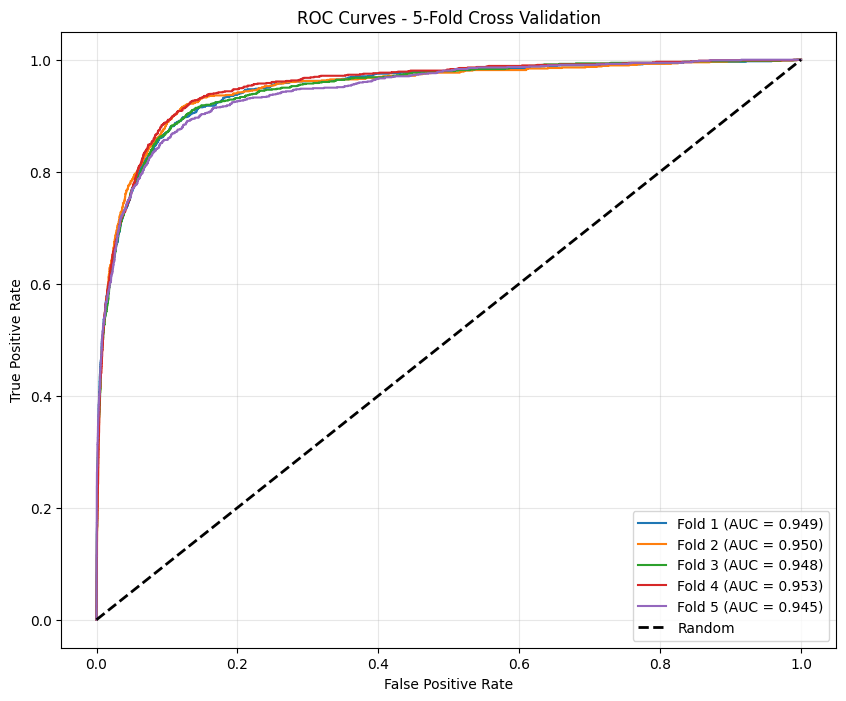


Average Performance Across All Folds:
Accuracie: 0.9459 ± 0.0022
Precision: 0.6883 ± 0.0294
Recall: 0.6911 ± 0.0289
F1: 0.6885 ± 0.0047
Auc: 0.9487 ± 0.0028

Average Optimal Threshold: 0.336

Training final model on entire dataset...
Epoch [10/200]
  Train Loss: 0.0200
  Val Loss: 0.1533
  Val F1: 0.6913, Precision: 0.6810, Recall: 0.7020, AUC: 0.9523
Epoch [20/200]
  Train Loss: 0.0054
  Val Loss: 0.2046
  Val F1: 0.6880, Precision: 0.7678, Recall: 0.6232, AUC: 0.9520
Epoch [30/200]
  Train Loss: 0.0028
  Val Loss: 0.2222
  Val F1: 0.7039, Precision: 0.7556, Recall: 0.6589, AUC: 0.9543
Epoch [40/200]
  Train Loss: 0.0019
  Val Loss: 0.2350
  Val F1: 0.6908, Precision: 0.7749, Recall: 0.6232, AUC: 0.9541
Early stopping at epoch 45

Final model saved to 'pytorch_final_model_improved.pth'

Training completed successfully!

Test Set Results:
Accuracy: 0.9525
Precision: 0.7339
Recall: 0.7073
F1 Score: 0.7204
AUC Score: 0.9588


In [58]:
# Convert string labels to binary (if not already done)
label_map = {"Normal": 0, "SV": 1}
y = np.array([label_map[label] for label in read_labels])

# Convert data to PyTorch tensors
X_tensor = torch.tensor(sample, dtype=torch.float32)  # Using the high-dimensional embeddings
y_tensor = torch.tensor(y, dtype=torch.long)

# Create train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor)
X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = torch.tensor(X_train), torch.tensor(X_test), torch.tensor(y_train), torch.tensor(y_test)

# Run the main training
print("Starting improved PyTorch training for imbalanced classification...")
final_model, results = main(X_train_tensor, y_train_tensor, use_ensemble=True)

# For ensemble (takes longer but potentially better results)
# final_model, results = main(X_tensor, y_tensor, use_ensemble=True)

print("\nTraining completed successfully!")


print("\nTest Set Results:")
loaded_model, optimal_threshold = load_improved_model('pytorch_final_model_improved.pth')

# Make predictions on new data
# new_data = torch.randn(10, n_features)  # Example new data
predictions, probabilities = predict_with_model(loaded_model, X_test, optimal_threshold)
# evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Precision: {precision_score(y_test, predictions):.4f}")
print(f"Recall: {recall_score(y_test, predictions):.4f}")
print(f"F1 Score: {f1_score(y_test, predictions):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, probabilities):.4f}")

In [22]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import KFold, StratifiedKFold
# from sklearn.neural_network import MLPClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
#                            confusion_matrix, roc_curve, roc_auc_score)
# import matplotlib.pyplot as plt
# import seaborn as sns
# from imblearn.over_sampling import SMOTE

# # Convert string labels to binary (if not already done)
# label_map = {"Normal": 0, "SV": 1}
# y = np.array([label_map[label] for label in read_labels])

# # Set up k-fold cross-validation
# n_splits = 5
# skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# # Create lists to store performance metrics for each fold
# fold_accuracies = []
# fold_precisions = []
# fold_recalls = []
# fold_f1s = []
# fold_aucs = []

# # Create a figure for ROC curves
# plt.figure(figsize=(10, 8))
# plt.plot([0, 1], [0, 1], 'k--', lw=2)

# # Perform k-fold cross-validation
# print(f"Performing {n_splits}-fold cross-validation...")
# for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
#     print(f"\nFold {fold+1}/{n_splits}")
    
#     # Split data for this fold
    
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]
    
#     # X_train, y_train = SMOTE(random_state=42, sampling_strategy='minority').fit_resample(X_train, y_train)
    
#     # Create the neural network pipeline
#     nn_pipeline = Pipeline([
#         ('scaler', StandardScaler()),
#         ('neural_network', MLPClassifier(
#             hidden_layer_sizes=(100),
#             max_iter=1000,
#             random_state=42,
#             early_stopping=True,
#             validation_fraction=0.2
#         ))
#     ])
    
#     # Train the model
#     print(f"  Training neural network for fold {fold+1}...")
#     nn_pipeline.fit(X_train, y_train)
    
#     # Make predictions
#     y_proba = nn_pipeline.predict_proba(X_test)[:,1]
#     # adjust threshold to 0.4
#     y_pred = (y_proba > 0.4).astype(int)
    
#     # Calculate metrics
#     accuracy = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
#     auc = roc_auc_score(y_test, y_proba)
    
#     # Store metrics
#     fold_accuracies.append(accuracy)
#     fold_precisions.append(precision)
#     fold_recalls.append(recall)
#     fold_f1s.append(f1)
#     fold_aucs.append(auc)
    
#     # Print results for this fold
#     print(f"  Fold {fold+1} Results:")
#     print(f"    Accuracy: {accuracy:.4f}")
#     print(f"    Precision: {precision:.4f}")
#     print(f"    Recall: {recall:.4f}")
#     print(f"    F1 Score: {f1:.4f}")
#     print(f"    AUC Score: {auc:.4f}")
    
#     # Plot ROC curve for this fold
#     fpr, tpr, _ = roc_curve(y_test, y_proba)
#     plt.plot(fpr, tpr, lw=2, alpha=0.7, label=f'Fold {fold+1} (AUC = {auc:.2f})')
    
#     # Save confusion matrix for each fold
#     cm = confusion_matrix(y_test, y_pred)
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#     plt.title(f"Confusion Matrix: Fold {fold+1}")
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.xticks([0.5, 1.5], ['Normal', 'SV'])
#     plt.yticks([0.5, 1.5], ['Normal', 'SV'])
#     plt.savefig(f'neural_network_fold_{fold+1}_confusion_matrix.png')
#     plt.close()

# # Calculate average performance across all folds
# mean_accuracy = np.mean(fold_accuracies)
# mean_precision = np.mean(fold_precisions)
# mean_recall = np.mean(fold_recalls)
# mean_f1 = np.mean(fold_f1s)
# mean_auc = np.mean(fold_aucs)

# std_accuracy = np.std(fold_accuracies)
# std_precision = np.std(fold_precisions)
# std_recall = np.std(fold_recalls)
# std_f1 = np.std(fold_f1s)
# std_auc = np.std(fold_aucs)

# # Print average results
# print("\nAverage Performance Across All Folds:")
# print(f"  Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
# print(f"  Precision: {mean_precision:.4f} ± {std_precision:.4f}")
# print(f"  Recall: {mean_recall:.4f} ± {std_recall:.4f}")
# print(f"  F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
# print(f"  AUC Score: {mean_auc:.4f} ± {std_auc:.4f}")

# # Finalize and save the ROC curve plot
# plt.figure(1)  # Return to the ROC plot
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title(f'ROC Curves for {n_splits}-Fold Cross-Validation')
# plt.legend(loc="lower right")
# plt.savefig('neural_network_kfold_roc_curves.png')
# plt.close()

# # Train a final model on the entire dataset
# print("\nTraining final model on the entire dataset...")
# final_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('neural_network', MLPClassifier(
#         hidden_layer_sizes=(200,40),
#         max_iter=1000,
#         random_state=42,
#         early_stopping=True,
#         validation_fraction=0.2
#     ))
# ])
# final_pipeline.fit(X, y)

# # Save the final model
# import joblib
# joblib.dump(final_pipeline, 'neural_network_final_model.pkl')

# # Create a bar plot showing performance metrics across folds
# metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
# means = [mean_accuracy, mean_precision, mean_recall, mean_f1, mean_auc]
# stds = [std_accuracy, std_precision, std_recall, std_f1, std_auc]

# plt.figure(figsize=(12, 6))
# bars = plt.bar(metrics, means, yerr=stds, capsize=10, alpha=0.7)
# plt.ylim(0, 1.1)
# plt.ylabel('Score')
# plt.title(f'Neural Network Performance Metrics ({n_splits}-Fold Cross-Validation)')

# # Add value labels on top of each bar
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
#              f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# plt.savefig('neural_network_kfold_metrics.png')
# plt.close()

# print("\nCross-validation complete. Final model saved and results visualized.")